# Experiment 3 — class-imbalance robustness (PD)

How AUC and **Adjusted AP** hold up as the minority-class proportion is driven down (no HPO; LogReg, TabICLv2, TabPFN-v3, and CatBoost). Pooled curves in four views for each metric, then per-dataset raw points, a degradation table, and a summary of both **trajectories**. Figures → `figures/experiment3/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, learning_curve_moving_average_with_dots,
    imbalance_curve, imbalance_curve_moving_average_with_dots, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
from src.utils.report import (notebook_report, capture, section,
                             preview)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment3')


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment3', task='pd', aggregated=False)
DISPLAY_METHODS = ['LogReg', 'tabicl_v2', 'tabpfn_v3', 'catboost']
missing = sorted(set(DISPLAY_METHODS) - set(df['method']))
if missing:
    preview(f'WARNING - no results for: {", ".join(missing)}')
df = df[df['method'].isin(DISPLAY_METHODS)].copy()


## 1. AUC vs minority-class proportion ? pooled over datasets

Views of the same curve (one line per method, mean over datasets): raw imbalance curve, the same curve with a lower-right inset zooming the shaded `minority proportion <= 0.025` region, moving average, and moving average with transparent raw points.


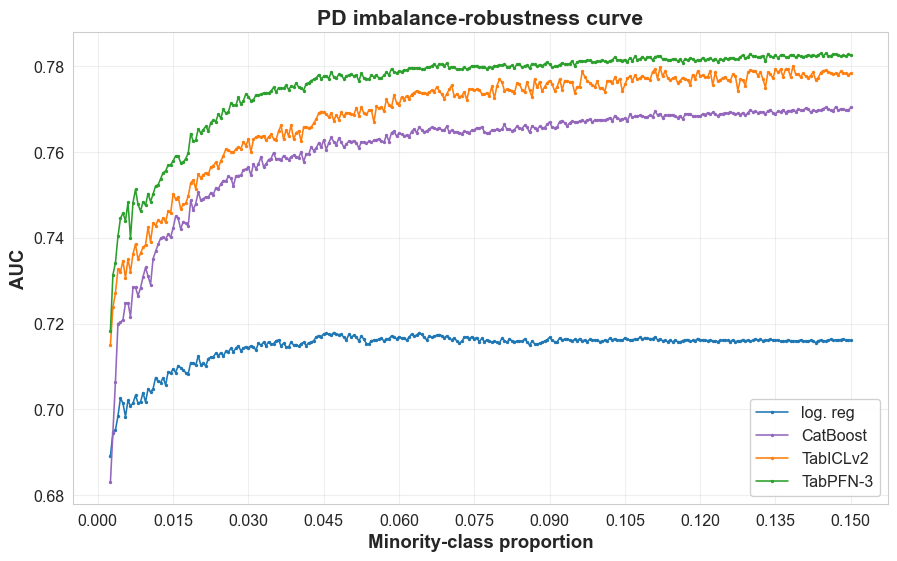

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc.pdf')

In [3]:
imbalance_curve(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)


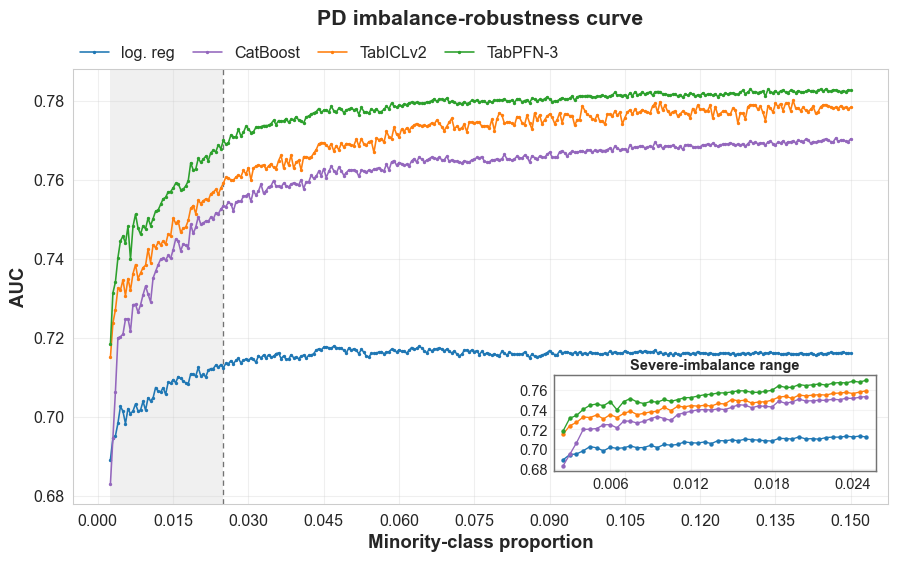

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc_zoom.pdf')

In [4]:
imbalance_curve(df, 'AUC', task_name='PD', zoom=True, out_dir=FIGURES_DIR)


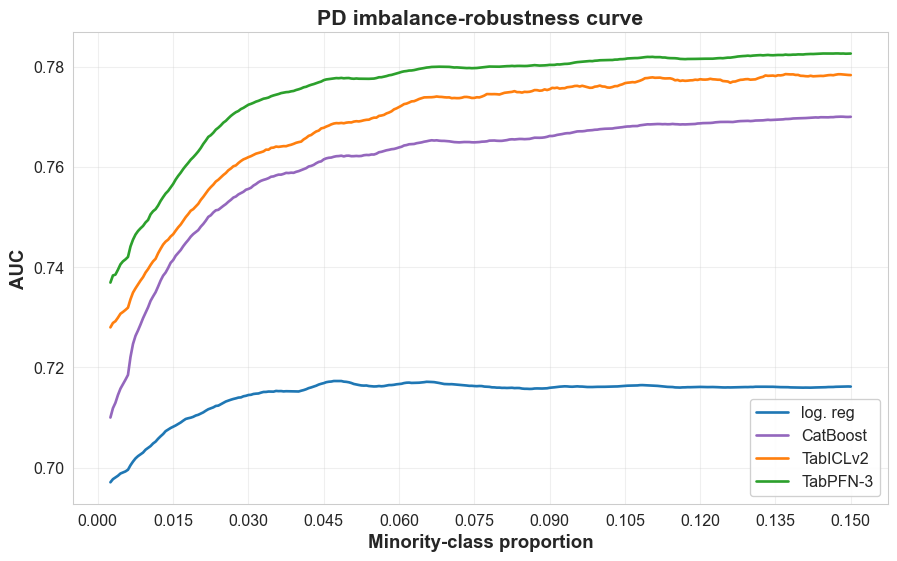

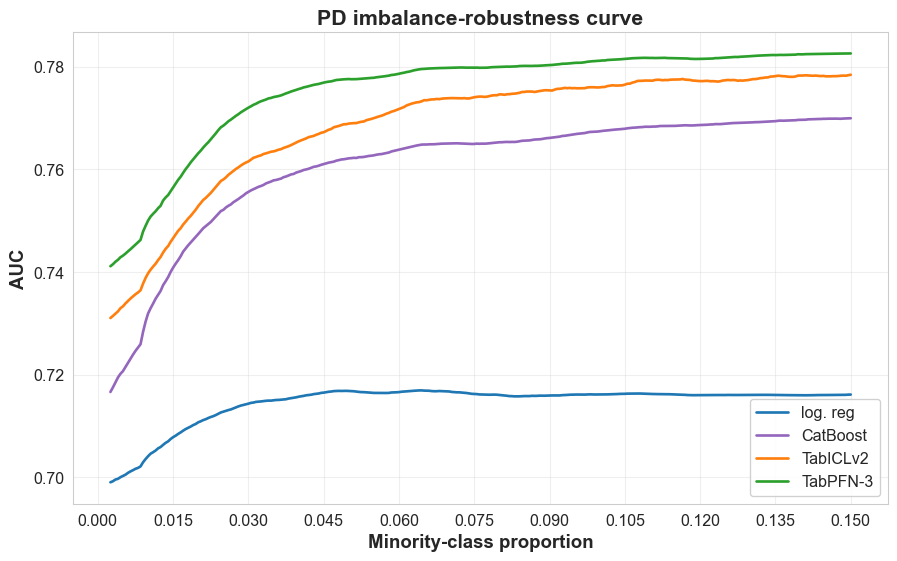

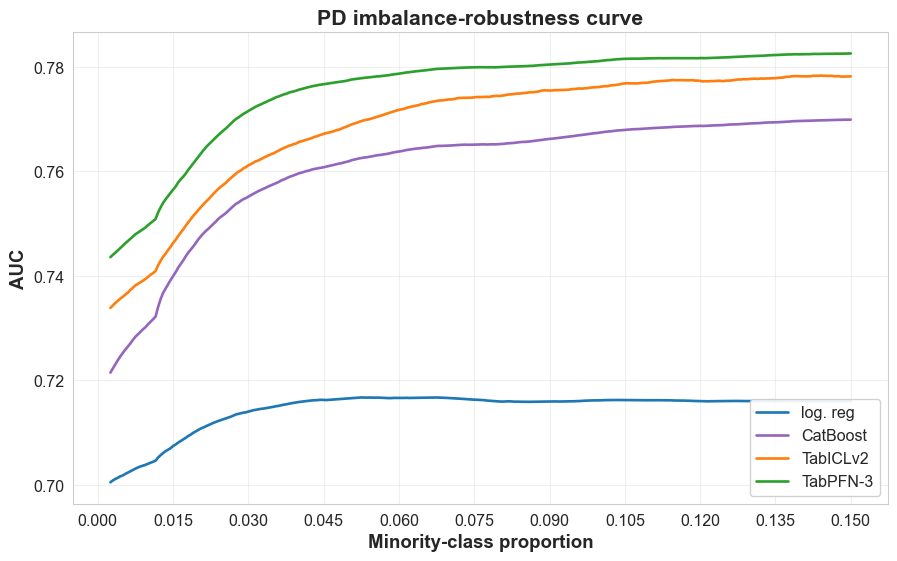

In [5]:
for smooth_window in ('less', 'standard', 'more'):
    imbalance_curve(df, 'AUC', task_name='PD', smooth=True, smooth_window=smooth_window, out_dir=FIGURES_DIR)


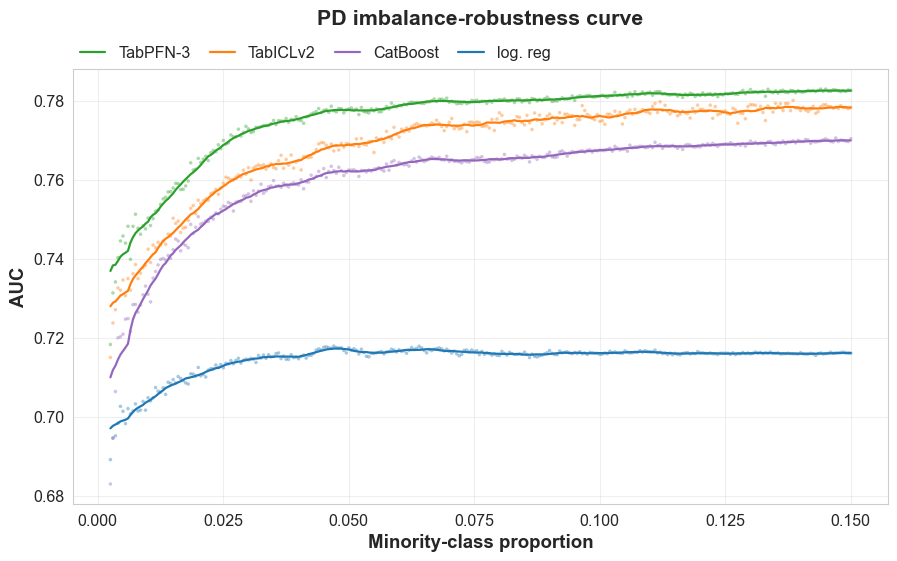

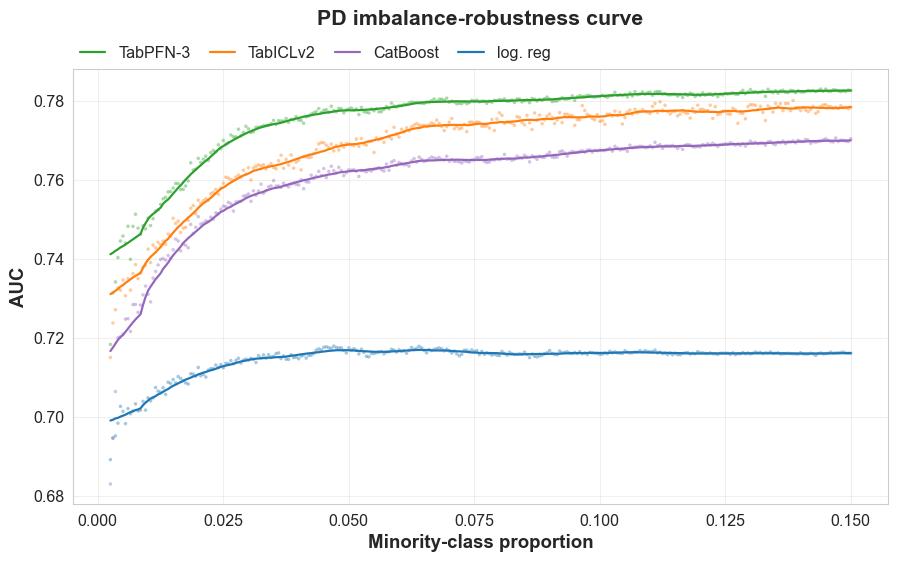

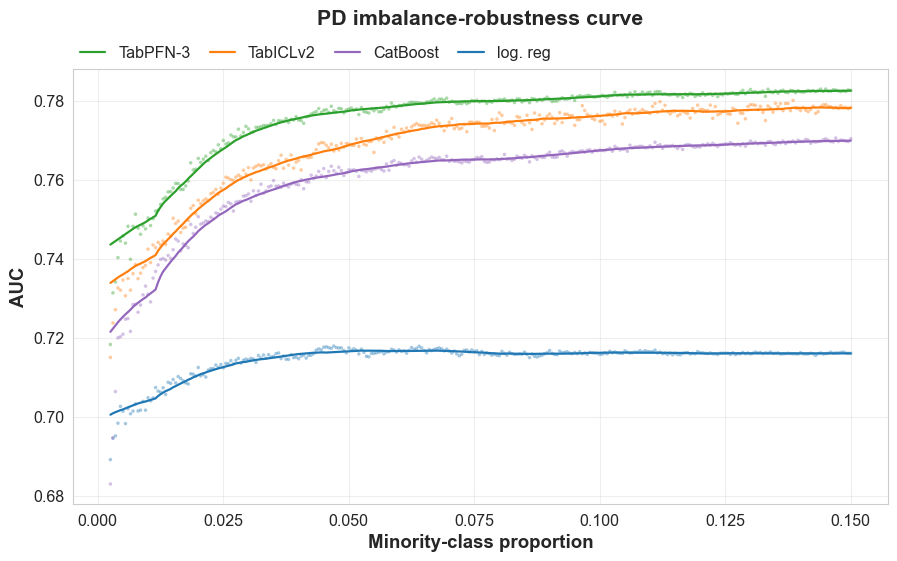

In [6]:
for smooth_window in ('less', 'standard', 'more'):
    imbalance_curve_moving_average_with_dots(df, 'AUC', task_name='PD', smooth_window=smooth_window, out_dir=FIGURES_DIR)


## 2. Adjusted AP — pooled over datasets

Same four views as above. AP_adjusted = (AP − π)/(1 − π) rescales AP so random ranking sits at 0 and perfect ranking at 1 on every dataset. That aligns the reference points; it does not remove all dependence on prevalence.


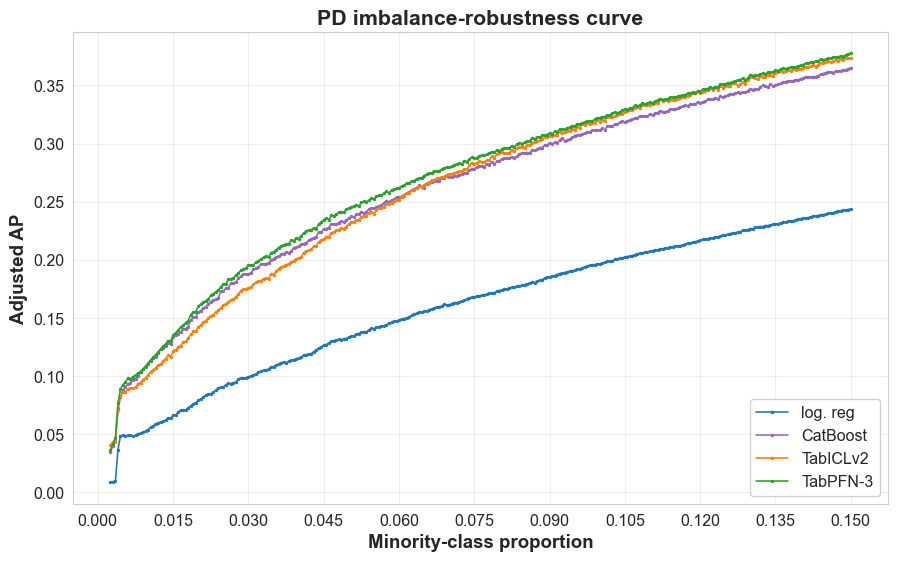

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_adjusted.pdf')

In [7]:
imbalance_curve(df, 'AP_adjusted', task_name='PD', out_dir=FIGURES_DIR)


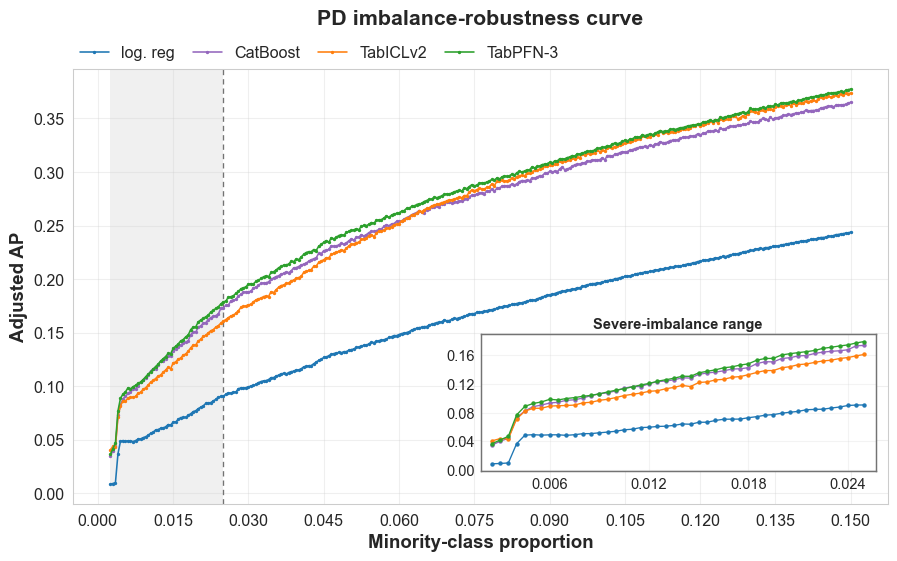

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_adjusted_zoom.pdf')

In [8]:
imbalance_curve(df, 'AP_adjusted', task_name='PD', zoom=True, out_dir=FIGURES_DIR)


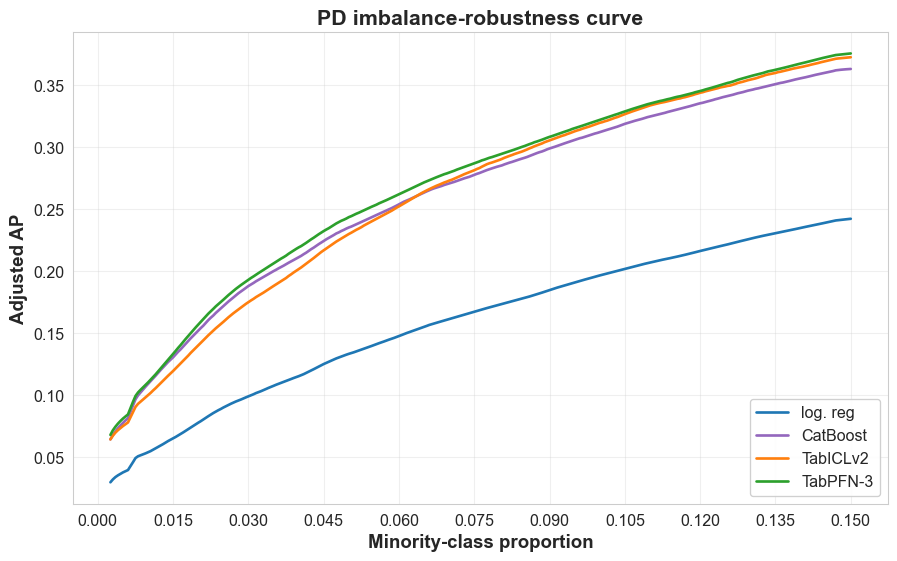

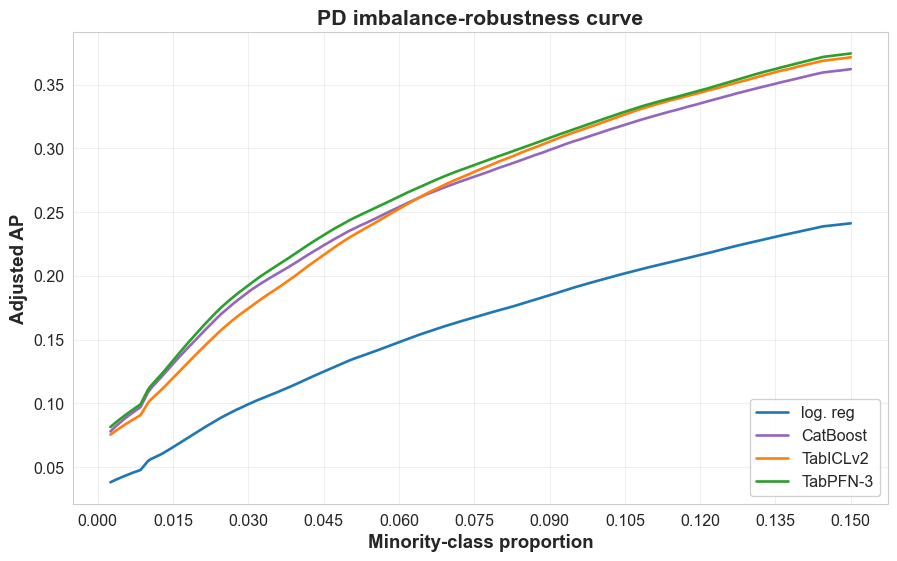

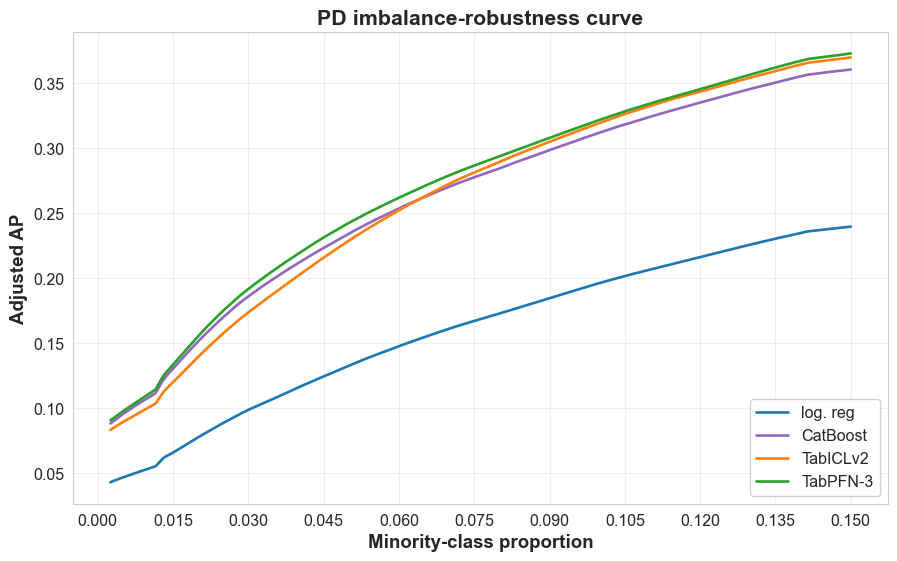

In [9]:
for smooth_window in ('less', 'standard', 'more'):
    imbalance_curve(df, 'AP_adjusted', task_name='PD', smooth=True, smooth_window=smooth_window, out_dir=FIGURES_DIR)


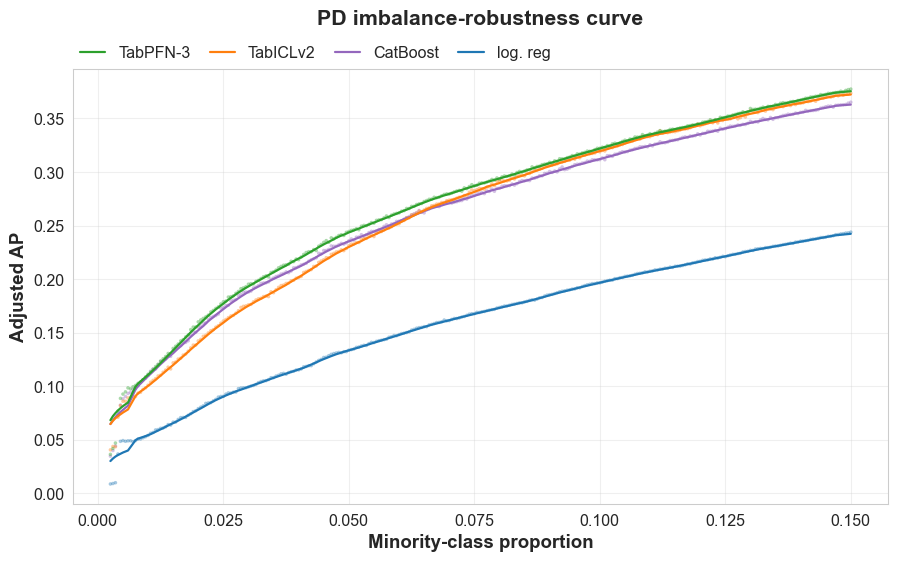

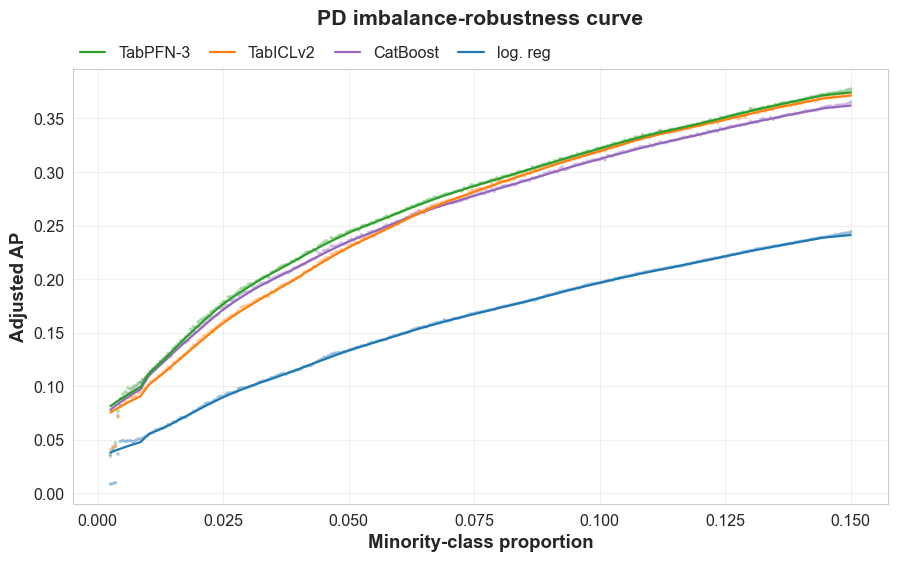

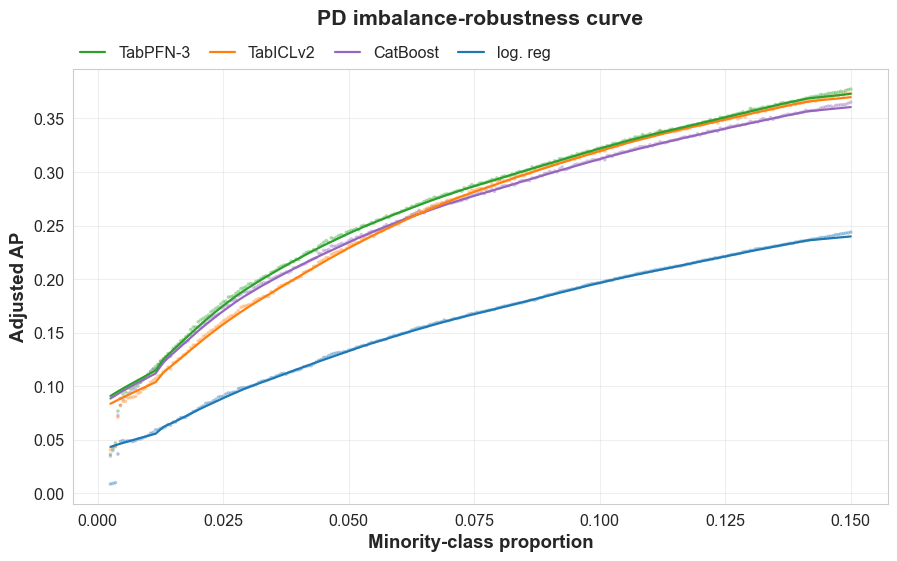

In [10]:
for smooth_window in ('less', 'standard', 'more'):
    imbalance_curve_moving_average_with_dots(df, 'AP_adjusted', task_name='PD', smooth_window=smooth_window, out_dir=FIGURES_DIR)


## 3. AUC per dataset (raw points, all methods)

One plot per dataset.

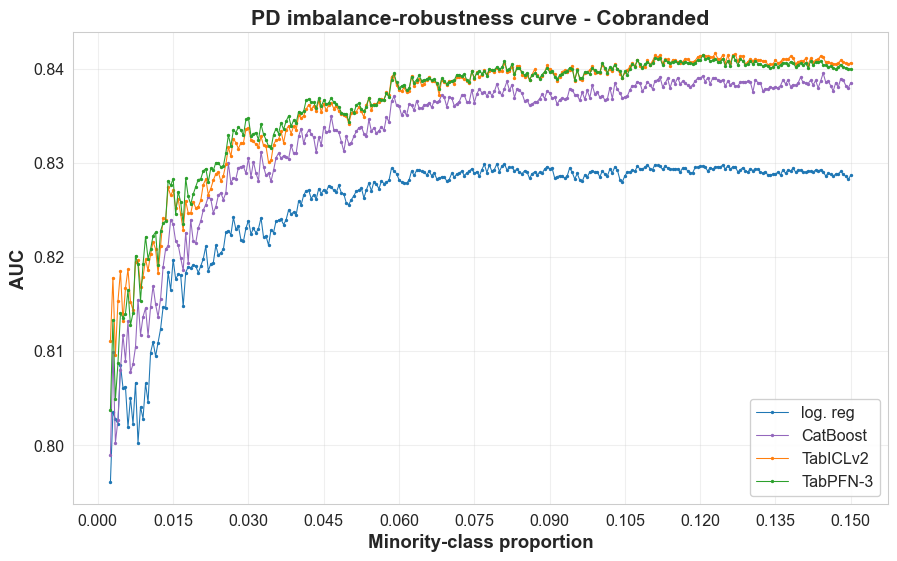

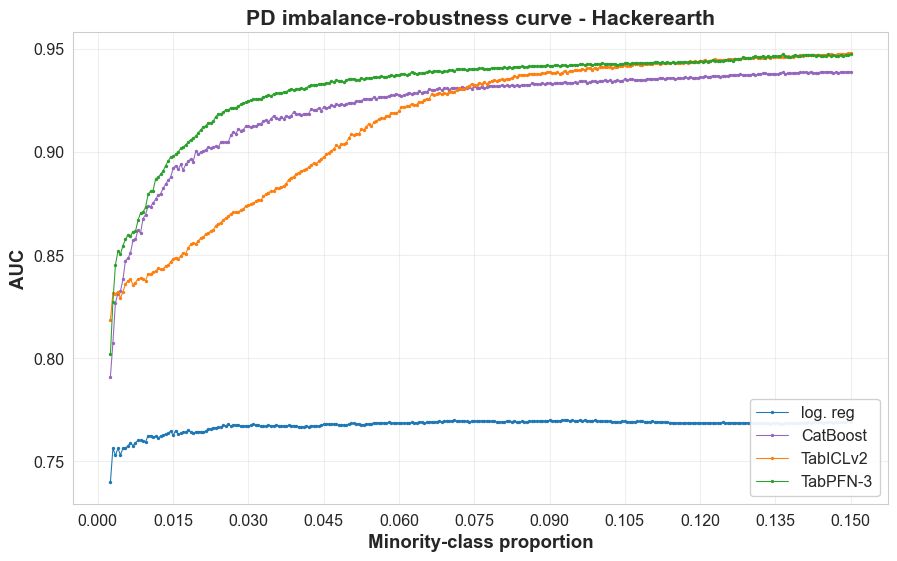

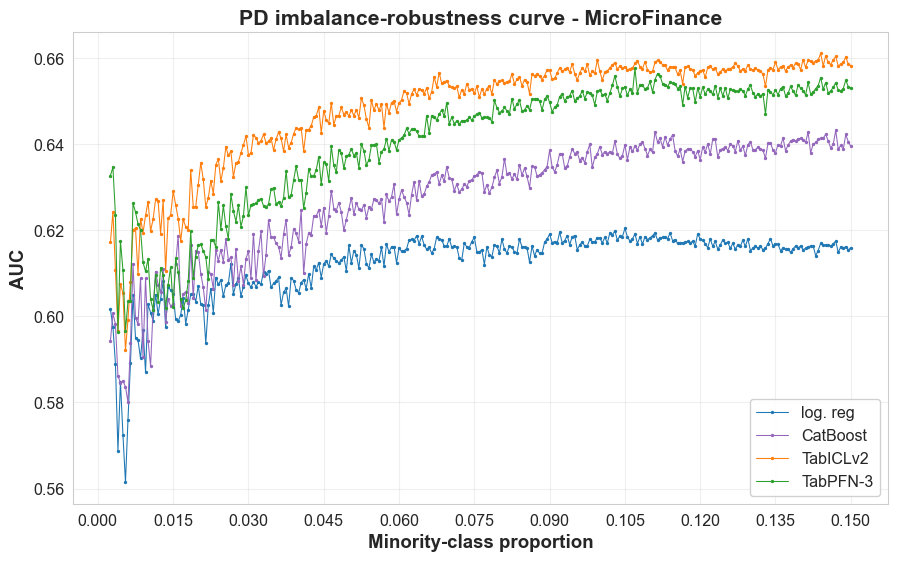

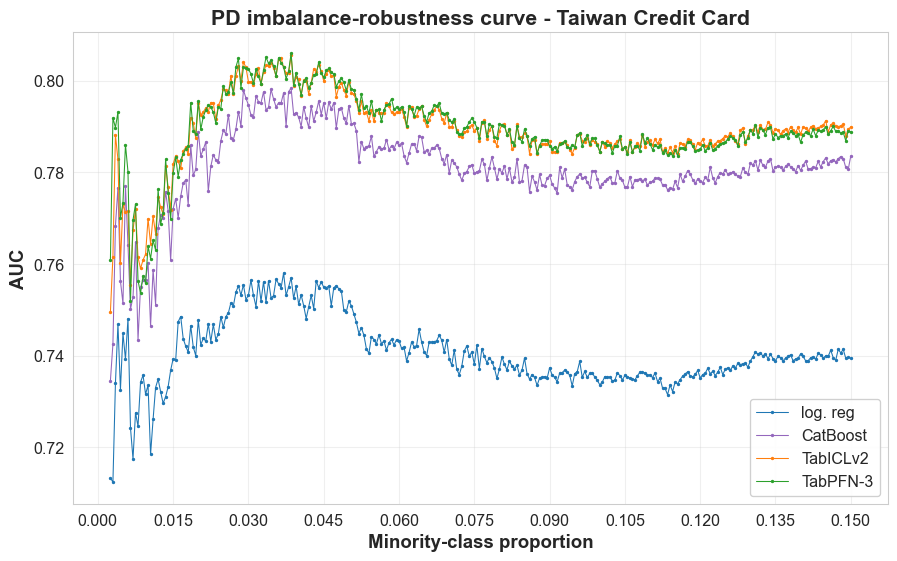

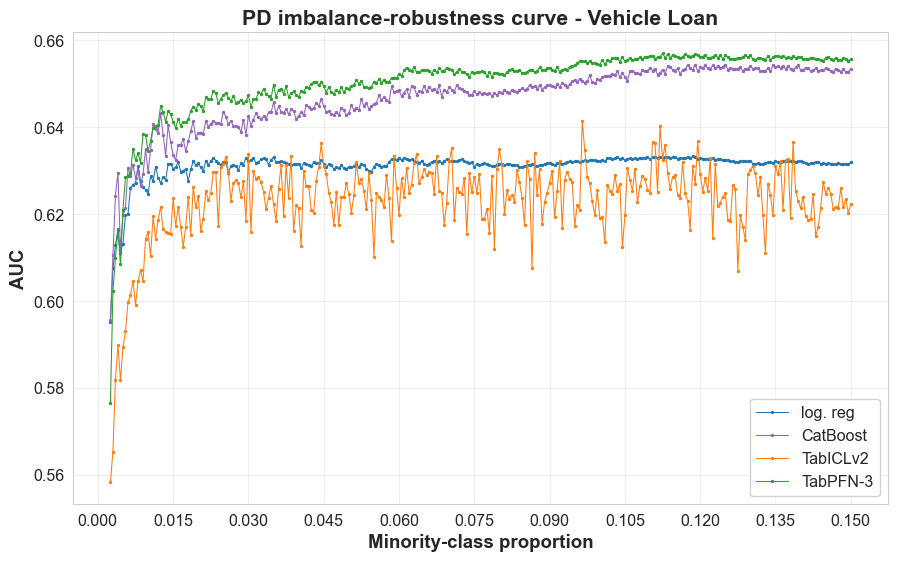

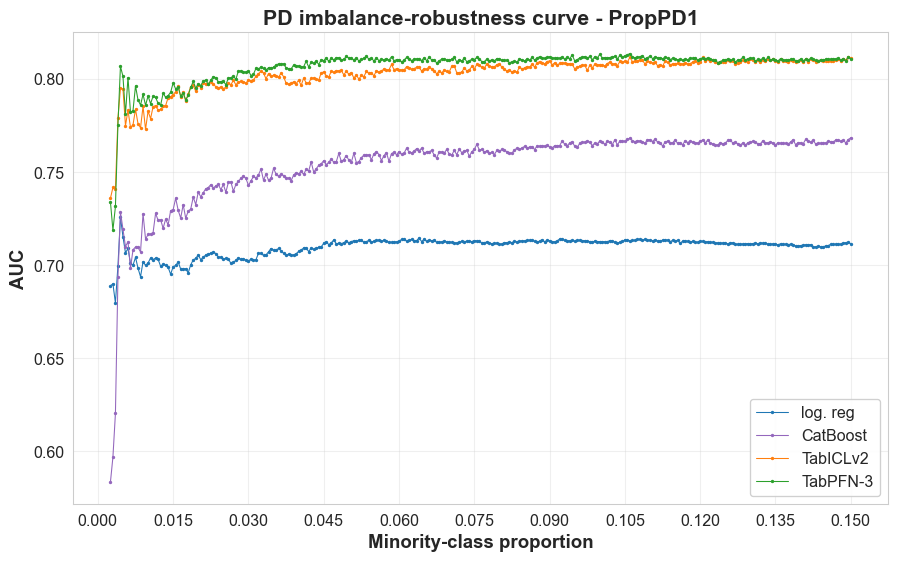

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0007_cobranded_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0006_hackerearth_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0014_algorithmwatch_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0002_taiwan_creditcard_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0003_vehicle_loan_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_proppd1_auc.pdf')]

In [11]:
per_dataset_sweep_curves(df, 'AUC', sweep_axis='minority_proportion', xlabel='Minority-class proportion', task_name='PD', out_dir=FIGURES_DIR)


## 4. Degradation — AUC at the easiest minus the hardest setting

In [12]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.AUC'].mean().reset_index()
drop = {m: gg.sort_values('sweep_value').iloc[-1]['metric.AUC']
            - gg.sort_values('sweep_value').iloc[0]['metric.AUC']
        for m, gg in g.groupby('method')}
preview(_pd.Series(drop, name='AUC(max minority) - AUC(min minority)')
        .sort_values(ascending=False),
        label='Degradation under imbalance')


**Degradation under imbalance**

catboost     0.087425
tabpfn_v3    0.064339
tabicl_v2    0.063325
LogReg       0.026918
Name: AUC(max minority) - AUC(min minority), dtype: float64

## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [13]:
notebook_report(
    'Experiment 3 - imbalance robustness',
    notebook='Experiment3.ipynb',
    about=('Class-imbalance sweep on PD: AUC and prevalence-corrected '
           'AP_adjusted versus the minority-class proportion (nested '
           'subsampling), pooled and per dataset.'),
    sections=[
        section('Sweep coverage',
                f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets, '
                f'{df["sweep_value"].nunique()} sweep points'),
        section('Degradation: AUC(max minority) - AUC(min minority) per method', _pd.Series(drop, name='AUC(max minority) - AUC(min minority)').sort_values(ascending=False)),
        section('AUC evolution across the whole sweep',
                capture(sweep_evolution_summary, df, 'AUC',
                        sweep_axis='minority_proportion', task_name='Experiment 3 - PD')),
        section('AP_adjusted evolution across the whole sweep',
                capture(sweep_evolution_summary, df, 'AP_adjusted',
                        sweep_axis='minority_proportion', task_name='Experiment 3 - PD')),
    ],
)

EXPERIMENT 3 - IMBALANCE ROBUSTNESS -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment3.ipynb
Contents        : Class-imbalance sweep on PD: AUC and prevalence-corrected AP_adjusted versus the minority-class proportion (nested subsampling), pooled and per dataset.
Sections        : 4

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] Sweep coverage
------------------------------------------------------------------------------
4 methods x 6 datasets, 296 sweep points

------------------------------------------------------------------------------
[2] Degradation: AUC(max minority) - AUC(min minority) per method
------------------------------------------------------------------------------
catboost     0.087425
tabpfn_v3    0.064339
tabicl_v2    0.063325
LogReg 

"==============================================================================\nEXPERIMENT 3 - IMBALANCE ROBUSTNESS -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment3.ipynb\nContents        : Class-imbalance sweep on PD: AUC and prevalence-corrected AP_adjusted versus the minority-class proportion (nested subsampling), pooled and per dataset.\nSections        : 4\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] Sweep coverage\n------------------------------------------------------------------------------\n4 methods x 6 datasets, 296 sweep points\n\n------------------------------------------------------------------------------\n[2] Degradation: AUC(max minority) - AUC(m